### Assessing Portfolio Performance

Assess the portfolio’s performance against that of the benchmark and the returns produced by three Technical Indicators (MACD, RSI and BB).

In [31]:
import os 
import pandas as pd 
import numpy as np 
import talib 
import matplotlib.pyplot as plt 
%matplotlib inline 
import datetime 
import warnings
warnings.filterwarnings('ignore') 

In [2]:
NVDA = pd.read_csv('NVDA_final.csv', index_col=0, parse_dates=True) 
MSFT = pd.read_csv('MSFT_final.csv', index_col=0, parse_dates=True) 
AAPL = pd.read_csv('AAPL_final.csv', index_col=0, parse_dates=True) 
AMZN = pd.read_csv('AMZN_final.csv', index_col=0, parse_dates=True) 
META = pd.read_csv('META_final.csv', index_col=0, parse_dates=True) 
TSLA = pd.read_csv('TSLA_final.csv', index_col=0, parse_dates=True) 

In [4]:
MSFT.columns 

Index(['Strategy Return', 'MACD Return', 'RSI Return', 'BB Return',
       'Buy & Hold Returns'],
      dtype='object')

### Returns Analysis

In [5]:
prop= (1/6) 

NVDA = NVDA*prop
MSFT = MSFT*prop
AAPL = AAPL*prop
AMZN = AMZN*prop
META = META*prop
TSLA = TSLA*prop 

In [7]:
NVDA.head(2) 

,Strategy Return,MACD Return,RSI Return,BB Return,Buy & Hold Returns
Date,,,,,
2021-02-22,-0.002500,-0.002500,0.000167,-0.002500,-0.002500
2021-02-23,0.004155,0.000167,0.000167,0.004155,0.004155


In [11]:
#Strategy Returns
Strategy_Returns = (NVDA['Strategy Return']+MSFT['Strategy Return']+AAPL['Strategy Return']+
                    AMZN['Strategy Return']+META['Strategy Return']+TSLA['Strategy Return']) 

In [12]:
Strategy_Returns 

Date
2021-02-22         NaN
2021-02-23         NaN
2021-02-24         NaN
2021-02-25         NaN
2021-02-26         NaN
                ...   
2024-06-12    0.008927
2024-06-13   -0.002359
2024-06-14    0.005453
2024-06-17   -0.000346
2024-06-18   -0.006163
Name: Strategy Return, Length: 837, dtype: float64

In [13]:
Strategy_Returns = pd.DataFrame(Strategy_Returns.values, columns=['Strategy Returns'],
                                index=Strategy_Returns.index) 

In [14]:
Strategy_Returns 

,Strategy Returns
Date,
2021-02-22,NaN
2021-02-23,NaN
2021-02-24,NaN
2021-02-25,NaN
2021-02-26,NaN
...,...
2024-06-12,0.008927
2024-06-13,-0.002359
2024-06-14,0.005453


In [15]:
#MACD Returns
MACD_Returns = (NVDA['MACD Return']+MSFT['MACD Return']+AAPL['MACD Return']+
                    AMZN['MACD Return']+META['MACD Return']+TSLA['MACD Return']) 
MACD_Returns = pd.DataFrame(MACD_Returns.values, columns=['MACD Returns'],
                                index=MACD_Returns.index) 

In [16]:
#RSI Returns
RSI_Returns = (NVDA['RSI Return']+MSFT['RSI Return']+AAPL['RSI Return']+
                    AMZN['RSI Return']+META['RSI Return']+TSLA['RSI Return']) 
RSI_Returns = pd.DataFrame(RSI_Returns.values, columns=['RSI Returns'],
                                index=RSI_Returns.index) 

In [17]:
#BB Returns
BB_Returns = (NVDA['BB Return']+MSFT['BB Return']+AAPL['BB Return']+
                    AMZN['BB Return']+META['BB Return']+TSLA['BB Return']) 
BB_Returns = pd.DataFrame(BB_Returns.values, columns=['BB Returns'],
                                index=BB_Returns.index) 

In [18]:
#Buy and Hold Returns
BH_Returns = (NVDA['Buy & Hold Returns']+MSFT['Buy & Hold Returns']+AAPL['Buy & Hold Returns']+
                    AMZN['Buy & Hold Returns']+META['Buy & Hold Returns']+TSLA['Buy & Hold Returns']) 
BH_Returns = pd.DataFrame(BH_Returns.values, columns=['BH Returns'],
                                index=BH_Returns.index) 

### Performance Analysis

In [19]:
dict = {'St_Rt':Strategy_Returns['Strategy Returns'], 'MACD_Rt':MACD_Returns['MACD Returns'], 'RSI_Rt':RSI_Returns['RSI Returns'],
        'BB_Rt':BB_Returns['BB Returns'], 'BH_Rt':BH_Returns['BH Returns']} 
df1 = []
df1 = pd.DataFrame(data=dict) 
df1.dropna(inplace=True) 
# train - 2516 , test - 838
df = df1[-838:] 

In [20]:
df.head() 

,St_Rt,MACD_Rt,RSI_Rt,BB_Rt,BH_Rt
Date,,,,,
2021-06-25,0.014607,0.025561,0.001,0.025561,0.025561
2021-06-28,0.004113,0.000409,0.001,0.000409,0.000409
2021-06-29,-0.000387,-0.002378,0.001,-0.002378,-0.002378
2021-06-30,0.001758,0.004929,0.001,0.004929,0.004929
2021-07-01,0.013290,0.009712,0.001,0.013290,0.013290


In [28]:
#Strategy Return 
Total_Strategy_Return = df['St_Rt'].sum() 
Cum_Strategy_Return = df['St_Rt'].cumsum() 
print('Strategy Return = ',Total_Strategy_Return) 

#MACD Return 
Total_MACD_Return = df['MACD_Rt'].sum() 
Cum_MACD_Return = df['MACD_Rt'].cumsum() 
print('MACD Return = ',Total_MACD_Return)  

#RSI Return 
Total_RSI_Return = df['RSI_Rt'].sum() 
Cum_RSI_Return = df['RSI_Rt'].cumsum() 
print('RSI Return = ',Total_RSI_Return)  

#BB Return 
Total_BB_Return = df['BB_Rt'].sum() 
Cum_BB_Return = df['BB_Rt'].cumsum() 
print('BB Return = ',Total_BB_Return)  

#BH Return 
Total_BH_Return = df['BH_Rt'].sum() 
Cum_BH_Return = df['BH_Rt'].cumsum() 
print('BH Return = ',Total_BH_Return) 


Strategy Return =  0.9098623062555942
MACD Return =  0.6450819179421918
RSI Return =  0.7742591317482495
BB Return =  0.5278292343249201
BH Return =  0.5278292343249201


### Plot Strategy Returns vs Benchmark vs (MACD, RSI, BB)

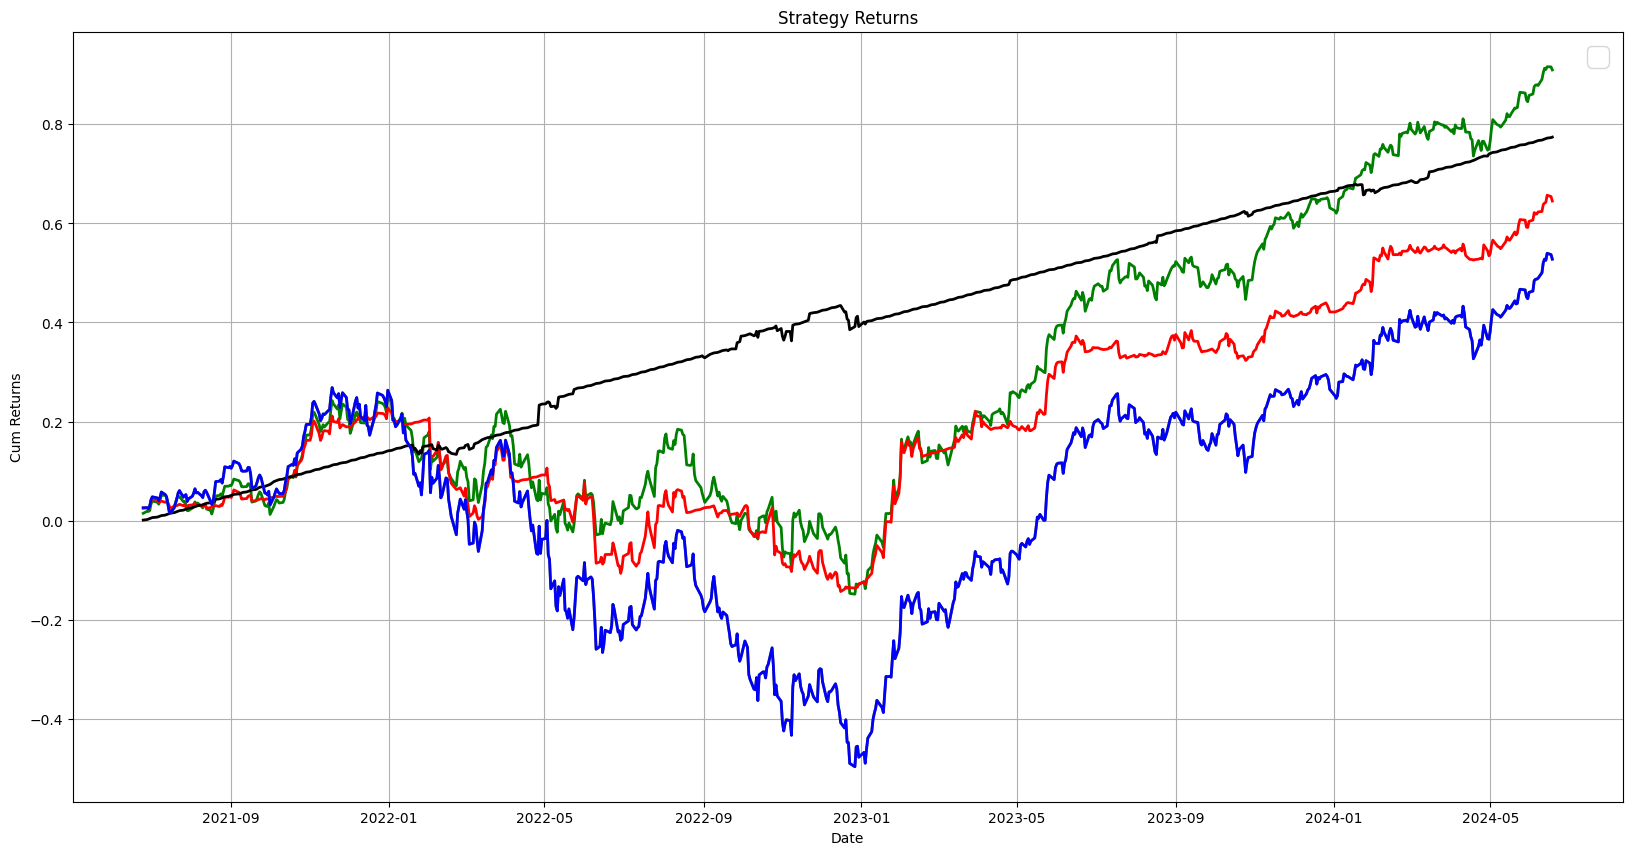

In [32]:
fig, ax = plt.subplots(figsize=(20,10))
ax.plot(df.index, Cum_Strategy_Return, linewidth=2, color='green')
ax.plot(df.index, Cum_MACD_Return, linewidth=2, color='red')
ax.plot(df.index, Cum_RSI_Return, linewidth=2, color='black')
ax.plot(df.index, Cum_BB_Return, linewidth=2, color='olive')
ax.plot(df.index, Cum_BH_Return, linewidth=2, color='blue')

ax.set(xlabel = 'Date', ylabel='Cum Returns', title='Strategy Returns')
ax.grid() 
ax.legend(fontsize=20, loc=0) 
plt.show() 

### Single Stock Contribution to Portfolio Performance

In [35]:
stocks = ['NVDA', 'MSFT', 'AAPL', 'AMZN', 'META', 'TSLA'] 

NVDA_Op = np.round(NVDA['Strategy Return'].sum()-NVDA['Buy & Hold Returns'].sum(),4)
MSFT_Op = np.round(MSFT['Strategy Return'].sum()-MSFT['Buy & Hold Returns'].sum(),4)
AAPL_Op = np.round(AAPL['Strategy Return'].sum()-AAPL['Buy & Hold Returns'].sum(),4)
AMZN_Op = np.round(AMZN['Strategy Return'].sum()-AMZN['Buy & Hold Returns'].sum(),4)
META_Op = np.round(META['Strategy Return'].sum()-META['Buy & Hold Returns'].sum(),4)
TSLA_Op = np.round(TSLA['Strategy Return'].sum()-TSLA['Buy & Hold Returns'].sum(),4)

In [40]:
Performance = [NVDA_Op, MSFT_Op, AAPL_Op, AMZN_Op, META_Op, TSLA_Op] 
dict = {'Stocks':stocks, 'Performance':Performance} 
dt = [] 
dt = pd.DataFrame(data=dict) 
dt.dropna(inplace=True) 
dt = dt.sort_values(by='Performance', ascending=False) 

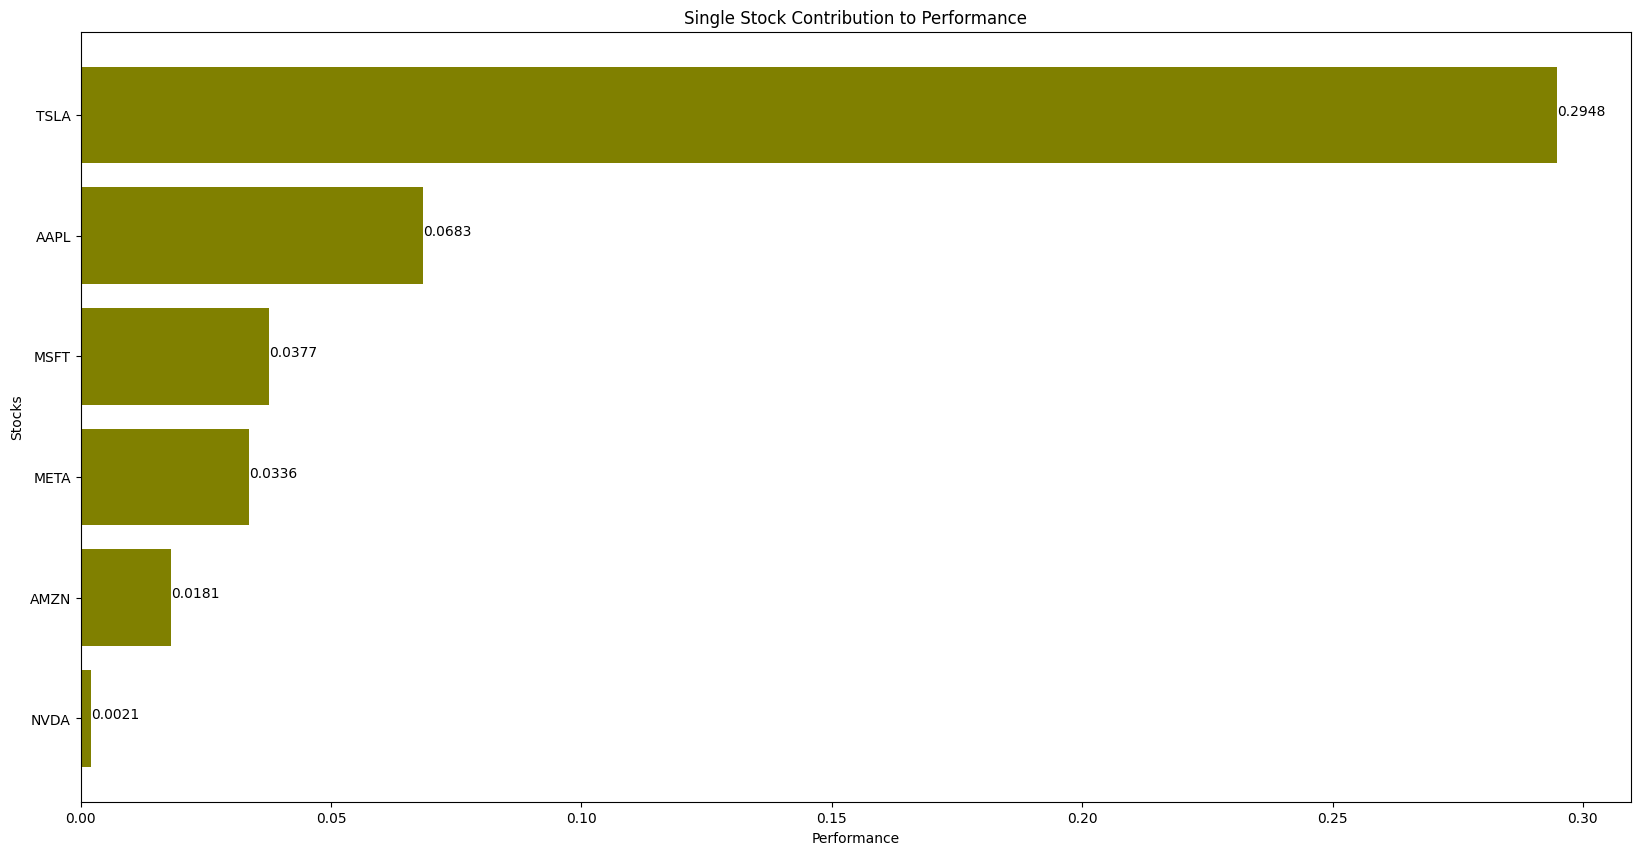

In [41]:
fig, ax = plt.subplots(figsize=(20,10))
ax.barh(dt['Stocks'],dt['Performance'],align='center',
        color='olive',ecolor='black') 
ax.set_yticks(dt['Stocks']) 
ax.invert_yaxis() 
ax.set_xlabel('Performance') 
ax.set_ylabel('Stocks') 
ax.set_title('Single Stock Contribution to Performance') 

for i, v in enumerate(dt['Performance']):
    ax.text(v, i, str(v), color='black',fontsize=10)

plt.show() 